# Jane Street 实时市场数据预测 - EDA（探索性数据分析）

## 项目概述
Jane Street Real-Time Market Data Forecasting 是一个量化交易竞赛，目标是预测金融市场的实时反应。

### 任务目标
- 预测 `responder_6` 的值（这是一个回归任务）
- 使用79个特征（feature_00 到 feature_78）
- 数据按时间和股票分组

### 关键概念
1. **Responder（响应变量）**: 表示市场对某种情况的反应，我们的目标是预测 responder_6
2. **Feature（特征）**: 市场数据和技术的描述符
3. **Time ID**: 每天的交易时间切片（0-967）
4. **Date ID**: 交易日期索引
5. **Symbol ID**: 股票/资产的唯一标识符（0-38，共39个）
6. **Weight（权重）**: 用于计算评估指标的样本权重
7. **Lag（滞后）**: 前一个时间点的responder值，作为额外的特征

## 1. 环境设置和数据加载

In [6]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置路径
DATA_PATH = Path('../Dataset')
print(f"数据路径: {DATA_PATH}")
print(f"数据路径存在: {DATA_PATH.exists()}")

数据路径: ../Dataset
数据路径存在: True


### 1.1 内存优化函数

**为什么要内存优化？**
- 数据集非常大（数百万行）
- 默认的数据类型（如float64）会占用大量内存
- 我们需要在有限的内存（<10GB）内处理数据

**优化策略：**
- 将float64降级为float32（精度损失很小，内存减半）
- 将int64降级为int32或更小的类型
- 使用category类型存储重复值多的列

In [7]:
def reduce_memory_usage(df, float16_as32=True):
    """
    优化DataFrame的内存使用
    
    参数:
        df: pandas DataFrame
        float16_as32: 是否将float16转为float32（为了更高的精度）
    
    返回:
        优化后的DataFrame
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'初始内存使用: {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object and str(col_type) != 'category':
            c_min, c_max = df[col].min(), df[col].max()
            
            if str(col_type)[:3] == 'int':
                # 整数类型优化
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                # 浮点类型优化
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32 if float16_as32 else np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'优化后内存使用: {end_mem:.2f} MB')
    print(f'减少了: {100 * (start_mem - end_mem) / start_mem:.1f}%')
    
    return df

print("内存优化函数已定义")

内存优化函数已定义


### 1.2 加载元数据

**元数据包含：**
- features.csv: 每个特征的标签（用于特征分组）
- responders.csv: 每个responder的标签

In [9]:
# 加载特征元数据
features_df = pd.read_csv(DATA_PATH / 'features.csv')
print("\n=== 特征元数据 ===")
print(f"总特征数: {len(features_df)}")
print(f"\n特征标签示例:\n{features_df.head(10)}")

# 加载responder元数据
responders_df = pd.read_csv(DATA_PATH / 'responders.csv')
print("\n=== Responder元数据 ===")
print(f"总responder数: {len(responders_df)}")
print(f"\nResponder信息:\n{responders_df}")


=== 特征元数据 ===
总特征数: 79

特征标签示例:
      feature  tag_0  tag_1  tag_2  tag_3  tag_4  tag_5  tag_6  tag_7  tag_8  \
0  feature_00  False  False   True  False  False  False  False  False  False   
1  feature_01  False  False   True  False  False  False  False  False  False   
2  feature_02  False  False   True  False  False  False  False  False  False   
3  feature_03  False  False   True  False  False  False  False  False  False   
4  feature_04  False  False   True  False  False  False  False  False  False   
5  feature_05  False  False  False   True  False  False  False  False  False   
6  feature_06  False  False  False   True  False  False  False  False  False   
7  feature_07  False  False  False   True  False  False  False  False  False   
8  feature_08  False  False  False   True  False  False  False  False  False   
9  feature_09  False   True  False  False  False  False  False  False  False   

   tag_9  tag_10  tag_11  tag_12  tag_13  tag_14  tag_15  tag_16  
0  False   False   

### 1.3 加载样本数据

**数据加载策略：**
- 只加载一个分区来探索数据结构
- 使用polars进行高效的延迟加载
- 转换为pandas进行详细分析

In [10]:
# 加载训练数据的一个分区（仅用于探索数据结构）
print("加载训练数据样本...")
train_path = DATA_PATH / 'train.parquet/partition_id=0/part-0.parquet'

# 使用polars快速加载
train_pl = pl.read_parquet(train_path)
print(f"\n数据形状: {train_pl.shape}")
print(f"\n列名:\n{train_pl.columns}")
print(f"\n数据类型:\n{train_pl.schema}")

# 转换为pandas
train_df = train_pl.to_pandas()
print(f"\n前5行数据:")
display(train_df.head())

# 内存优化
train_df = reduce_memory_usage(train_df)

加载训练数据样本...

数据形状: (1944210, 92)

列名:
['date_id', 'time_id', 'symbol_id', 'weight', 'feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'featu

,date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,...,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
0,0,0,1,3.889038,NaN,NaN,NaN,NaN,NaN,0.851033,...,-0.281498,0.738489,-0.069556,1.380875,2.005353,0.186018,1.218368,0.775981,0.346999,0.095504
1,0,0,7,1.370613,NaN,NaN,NaN,NaN,NaN,0.676961,...,-0.302441,2.965889,1.190077,-0.523998,3.849921,2.626981,5.000000,0.703665,0.216683,0.778639
2,0,0,9,2.285698,NaN,NaN,NaN,NaN,NaN,1.056285,...,-0.096792,-0.864488,-0.280303,-0.326697,0.375781,1.271291,0.099793,2.109352,0.670881,0.772828
3,0,0,10,0.690606,NaN,NaN,NaN,NaN,NaN,1.139366,...,-0.296244,0.408499,0.223992,2.294888,1.097444,1.225872,1.225376,1.114137,0.775199,-1.379516
4,0,0,14,0.440570,NaN,NaN,NaN,NaN,NaN,0.955200,...,3.418133,-0.373387,-0.502764,-0.348021,-3.928148,-1.591366,-5.000000,-3.572820,-1.089123,-5.000000


初始内存使用: 654.51 MB
优化后内存使用: 654.51 MB
减少了: 0.0%


## 2. 数据结构理解

In [11]:
print("=== 数据基本信息 ===")
print(f"数据形状: {train_df.shape}")
print(f"\n数据类型统计:")
print(train_df.dtypes.value_counts())

print(f"\n缺失值统计:")
missing_stats = train_df.isnull().sum()[train_df.isnull().sum() > 0]
print(missing_stats.head(20))

print(f"\n有缺失值的列数: {len(missing_stats)}")

=== 数据基本信息 ===
数据形状: (1944210, 92)

数据类型统计:
float32    86
int16       3
int8        3
Name: count, dtype: int64

缺失值统计:
feature_00    1944210
feature_01    1944210
feature_02    1944210
feature_03    1944210
feature_04    1944210
feature_08      16980
feature_15      54992
feature_16         63
feature_17       9232
feature_18         59
feature_19         59
feature_21    1944210
feature_26    1944210
feature_27    1944210
feature_31    1944210
feature_32      21737
feature_33      21737
feature_39     324732
feature_40      38328
feature_41      97113
dtype: int64

有缺失值的列数: 44


### 2.1 关键列分析

**重要列说明：**
- `date_id`: 交易日期（0-1699，共1700天）
- `time_id`: 每天的时间切片（0-967，共968个）
- `symbol_id`: 股票ID（0-38，共39个）
- `weight`: 样本权重，用于评估指标计算
- `responder_6`: 我们的目标变量
- `feature_xx`: 79个市场特征

In [12]:
# 分析关键列
key_columns = ['date_id', 'time_id', 'symbol_id', 'weight', 'responder_6']

for col in key_columns:
    if col in train_df.columns:
        print(f"\n=== {col} ===")
        print(f"范围: {train_df[col].min()} 到 {train_df[col].max()}")
        print(f"唯一值数量: {train_df[col].nunique()}")
        print(f"缺失值数量: {train_df[col].isnull().sum()}")


=== date_id ===
范围: 0 到 169
唯一值数量: 170
缺失值数量: 0

=== time_id ===
范围: 0 到 848
唯一值数量: 849
缺失值数量: 0

=== symbol_id ===
范围: 0 到 38
唯一值数量: 20
缺失值数量: 0

=== weight ===
范围: 0.4405696392059326 到 6.011998653411865
唯一值数量: 2290
缺失值数量: 0

=== responder_6 ===
范围: -5.0 到 5.0
唯一值数量: 1919683
缺失值数量: 0


## 3. 目标变量分析 (responder_6)

=== responder_6 统计信息 ===
count    1.944210e+06
mean     1.487634e-03
std      8.705768e-01
min     -5.000000e+00
25%     -3.558709e-01
50%     -9.597129e-03
75%      3.360999e-01
max      5.000000e+00
Name: responder_6, dtype: float64


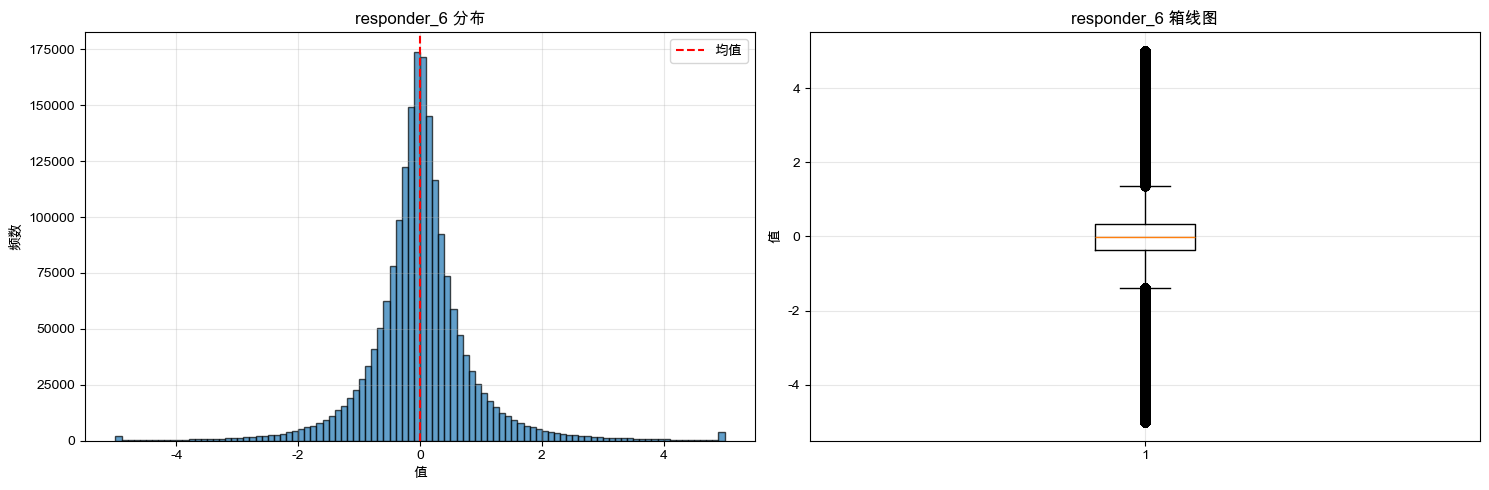


目标变量的零值比例: 0.00%


In [13]:
# 目标变量统计
target = 'responder_6'
print(f"=== {target} 统计信息 ===")
print(train_df[target].describe())

# 可视化目标变量分布
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 直方图
axes[0].hist(train_df[target].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title(f'{target} 分布')
axes[0].set_xlabel('值')
axes[0].set_ylabel('频数')
axes[0].axvline(train_df[target].mean(), color='red', linestyle='--', label='均值')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 箱线图
axes[1].boxplot(train_df[target].dropna(), vert=True)
axes[1].set_title(f'{target} 箱线图')
axes[1].set_ylabel('值')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n目标变量的零值比例: {(train_df[target] == 0).mean():.2%}")

### 3.1 目标变量随时间变化

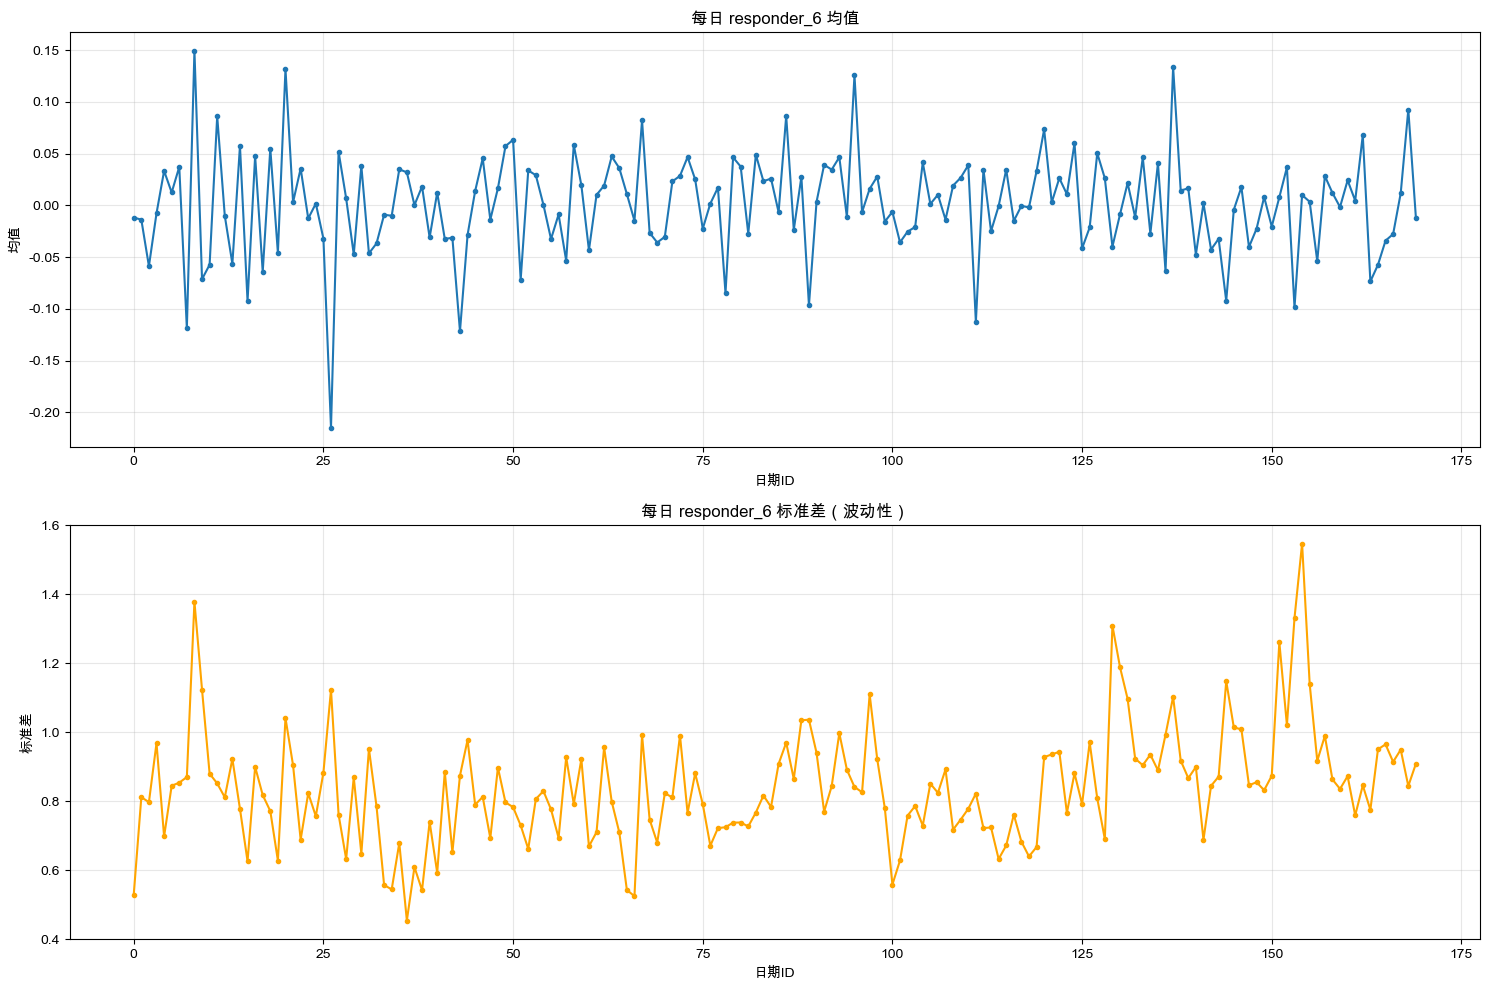


目标变量的时间统计:
- 日均均值: 0.001154
- 日均标准差: 0.839081
- 最大单日均值: 0.149477
- 最小单日均值: -0.214951


In [14]:
# 按日期聚合目标变量
daily_target = train_df.groupby('date_id')[target].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 每日均值
axes[0].plot(daily_target.index, daily_target['mean'], marker='o', markersize=3)
axes[0].set_title(f'每日 {target} 均值')
axes[0].set_xlabel('日期ID')
axes[0].set_ylabel('均值')
axes[0].grid(True, alpha=0.3)

# 每日标准差
axes[1].plot(daily_target.index, daily_target['std'], marker='o', markersize=3, color='orange')
axes[1].set_title(f'每日 {target} 标准差（波动性）')
axes[1].set_xlabel('日期ID')
axes[1].set_ylabel('标准差')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n目标变量的时间统计:")
print(f"- 日均均值: {daily_target['mean'].mean():.6f}")
print(f"- 日均标准差: {daily_target['std'].mean():.6f}")
print(f"- 最大单日均值: {daily_target['mean'].max():.6f}")
print(f"- 最小单日均值: {daily_target['mean'].min():.6f}")

### 3.2 目标变量按股票分析

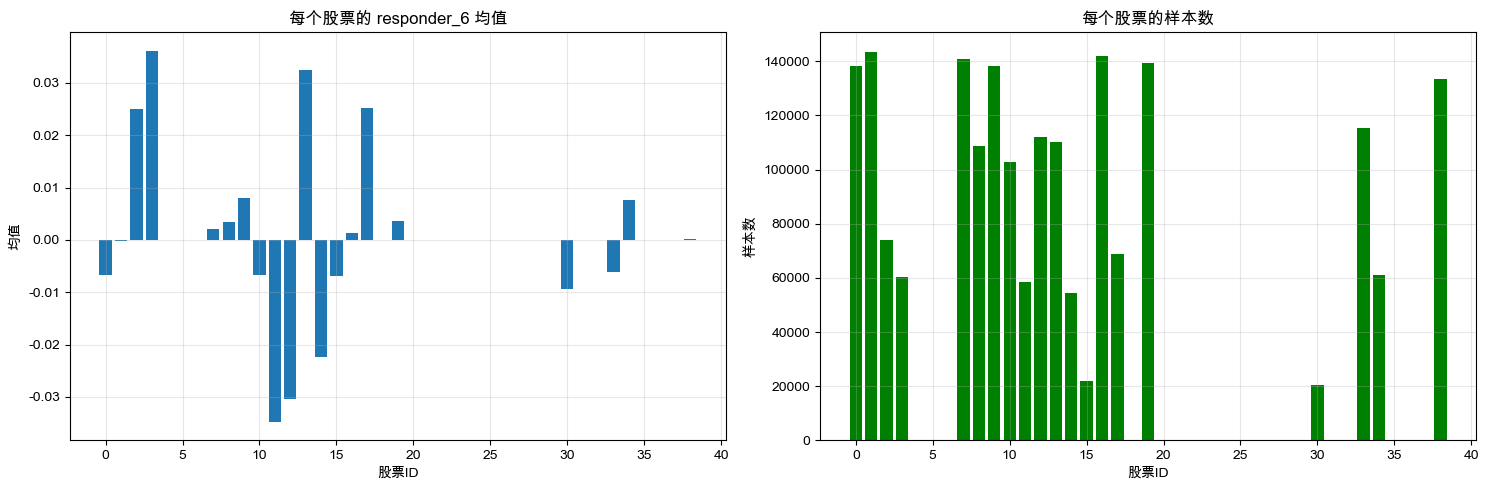


股票统计:
- 股票数量: 20
- 每个股票平均样本数: 97210
- 样本数最多: 143481 (股票 1)
- 样本数最少: 20376 (股票 30)


In [15]:
# 按股票聚合目标变量
symbol_target = train_df.groupby('symbol_id')[target].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 每个股票的均值
axes[0].bar(symbol_target.index, symbol_target['mean'])
axes[0].set_title(f'每个股票的 {target} 均值')
axes[0].set_xlabel('股票ID')
axes[0].set_ylabel('均值')
axes[0].grid(True, alpha=0.3)

# 每个股票的样本数
axes[1].bar(symbol_target.index, symbol_target['count'], color='green')
axes[1].set_title(f'每个股票的样本数')
axes[1].set_xlabel('股票ID')
axes[1].set_ylabel('样本数')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n股票统计:")
print(f"- 股票数量: {len(symbol_target)}")
print(f"- 每个股票平均样本数: {symbol_target['count'].mean():.0f}")
print(f"- 样本数最多: {symbol_target['count'].max()} (股票 {symbol_target['count'].idxmax()})")
print(f"- 样本数最少: {symbol_target['count'].min()} (股票 {symbol_target['count'].idxmin()})")

## 4. 特征分析

In [16]:
# 提取特征列
feature_cols = [col for col in train_df.columns if col.startswith('feature_')]
print(f"特征列数量: {len(feature_cols)}")
print(f"\n特征列: {feature_cols[:10]}... (显示前10个)")

特征列数量: 79

特征列: ['feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09']... (显示前10个)


### 4.1 特征缺失值分析

=== 特征缺失值统计 ===
有缺失值的特征数: 44

缺失值比例最高的20个特征:
feature_00    1.000000
feature_21    1.000000
feature_02    1.000000
feature_03    1.000000
feature_04    1.000000
feature_01    1.000000
feature_31    1.000000
feature_27    1.000000
feature_26    1.000000
feature_42    0.167025
feature_39    0.167025
feature_53    0.150766
feature_50    0.150766
feature_66    0.085574
feature_46    0.085574
feature_65    0.085574
feature_45    0.085574
feature_62    0.079209
feature_64    0.070187
feature_63    0.068549
dtype: float64


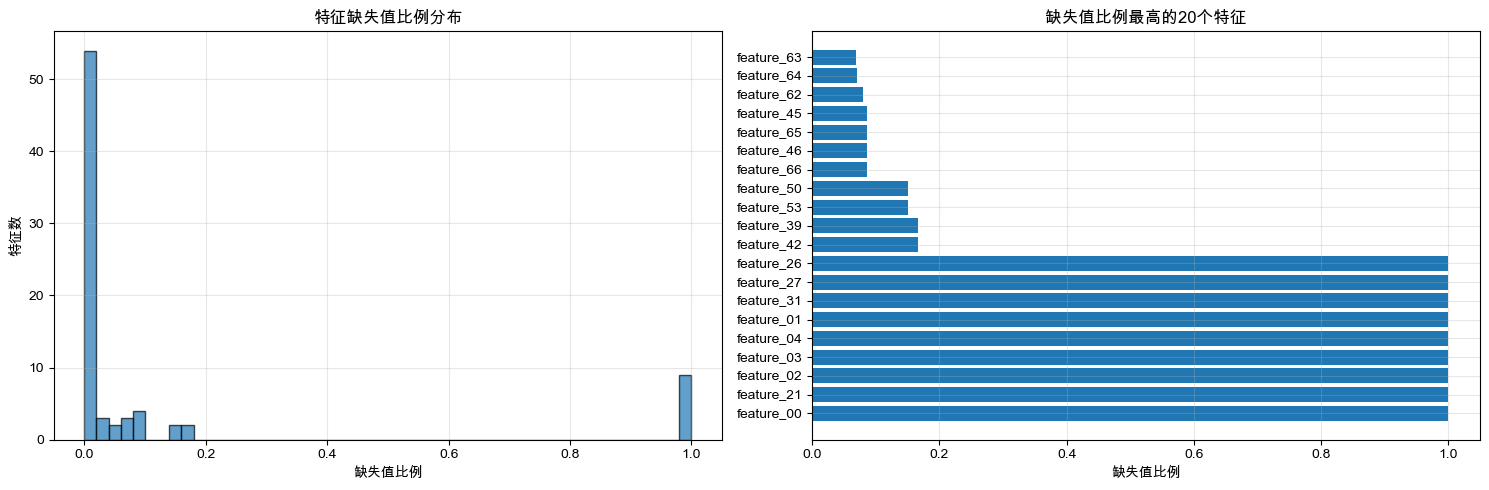

In [17]:
# 计算每个特征的缺失值比例
feature_missing = train_df[feature_cols].isnull().mean().sort_values(ascending=False)

print("=== 特征缺失值统计 ===")
print(f"有缺失值的特征数: {(feature_missing > 0).sum()}")
print(f"\n缺失值比例最高的20个特征:")
print(feature_missing.head(20))

# 可视化缺失值
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 缺失值比例分布
axes[0].hist(feature_missing, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('特征缺失值比例分布')
axes[0].set_xlabel('缺失值比例')
axes[0].set_ylabel('特征数')
axes[0].grid(True, alpha=0.3)

# 缺失值比例最高的特征
top_missing = feature_missing.head(20)
axes[1].barh(range(len(top_missing)), top_missing.values)
axes[1].set_yticks(range(len(top_missing)))
axes[1].set_yticklabels(top_missing.index)
axes[1].set_title('缺失值比例最高的20个特征')
axes[1].set_xlabel('缺失值比例')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 特征统计信息

In [18]:
# 计算特征统计信息
feature_stats = train_df[feature_cols].describe().T
feature_stats['missing_ratio'] = train_df[feature_cols].isnull().mean()
feature_stats['unique_ratio'] = train_df[feature_cols].nunique() / len(train_df)

print("=== 特征统计摘要 ===")
print(f"\n均值范围: {feature_stats['mean'].min():.4f} 到 {feature_stats['mean'].max():.4f}")
print(f"标准差范围: {feature_stats['std'].min():.4f} 到 {feature_stats['std'].max():.4f}")
print(f"\n特征统计前10行:")
display(feature_stats.head(10))

=== 特征统计摘要 ===

均值范围: -0.9993 到 168.0162
标准差范围: 0.6352 到 174.2217

特征统计前10行:


,count,mean,std,min,25%,50%,75%,max,missing_ratio,unique_ratio
feature_00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
feature_01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
feature_02,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
feature_03,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
feature_04,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
feature_05,1944210.0,-0.044632,0.947958,-11.766080,-0.475607,-0.058182,0.349377,15.319997,0.000000,0.989793
feature_06,1944210.0,-0.006456,0.935119,-25.143543,-0.341202,-0.011917,0.303610,24.158113,0.000000,0.991049
feature_07,1944210.0,-0.019842,0.967365,-20.321791,-0.416889,-0.033278,0.341909,28.097809,0.000000,0.990208
feature_08,1927230.0,0.059797,0.922840,-6.224619,-0.420154,0.029551,0.468864,13.068775,0.008734,0.980572
feature_09,1944210.0,28.628384,23.910034,4.000000,11.000000,11.000000,50.000000,81.000000,0.000000,0.000006


### 4.3 特征与目标变量的相关性

In [ ]:
# 计算特征与目标变量的相关性（使用样本数据加速）
sample_size = min(100000, len(train_df))
sample_df = train_df.sample(n=sample_size, random_state=42)

# 只计算非空特征的相关性
valid_features = [col for col in feature_cols if sample_df[col].notna().sum() > sample_size * 0.5]

correlations = {}
for col in valid_features:
    # 使用非缺失值计算相关性
    valid_idx = sample_df[col].notna() & sample_df[target].notna()
    if valid_idx.sum() > 100:
        corr = sample_df.loc[valid_idx, [col, target]].corr().iloc[0, 1]
        correlations[col] = corr

corr_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'correlation'])
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)

print(f"\n=== 与目标变量相关性最高的20个特征 ===")
print(corr_df.head(20))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 相关性最高的10个特征
top_corr = corr_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_corr['correlation']]
axes[0].barh(range(len(top_corr)), top_corr['correlation'], color=colors)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr['feature'])
axes[0].set_title(f'与 {target} 相关性最高的10个特征')
axes[0].set_xlabel('相关系数')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# 相关性分布
axes[1].hist(corr_df['correlation'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('特征-目标变量相关性分布')
axes[1].set_xlabel('相关系数')
axes[1].set_ylabel('特征数')
axes[1].axvline(x=0, color='red', linestyle='--', label='零相关')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 权重分析

In [ ]:
# 权重统计
print("=== Weight 统计 ===")
print(train_df['weight'].describe())

# 可视化权重分布
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 权重分布
axes[0].hist(train_df['weight'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('权重分布')
axes[0].set_xlabel('权重值')
axes[0].set_ylabel('频数')
axes[0].grid(True, alpha=0.3)

# 权重累积分布
sorted_weights = np.sort(train_df['weight'])
cumsum = np.cumsum(sorted_weights)
cumsum = cumsum / cumsum[-1]
axes[1].plot(sorted_weights, cumsum)
axes[1].set_title('权重累积分布')
axes[1].set_xlabel('权重值')
axes[1].set_ylabel('累积比例')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='50%')
axes[1].axhline(y=0.8, color='orange', linestyle='--', label='80%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n权重分析:")
print(f"- 权重为0的样本比例: {(train_df['weight'] == 0).mean():.2%}")
print(f"- 权重中位数: {train_df['weight'].median():.6f}")
print(f"- 50%的权重由前 {(cumsum <= 0.5).sum():.0f} 个样本贡献")

## 6. 数据质量检查

In [ ]:
print("=== 数据质量检查 ===")

# 1. 检查重复行
duplicates = train_df.duplicated().sum()
print(f"1. 重复行数: {duplicates}")

# 2. 检查异常值（使用3倍标准差规则）
numeric_cols = feature_cols + ['weight', target]
outlier_info = {}
for col in numeric_cols:
    if col in train_df.columns:
        mean_val = train_df[col].mean()
        std_val = train_df[col].std()
        outliers = ((train_df[col] - mean_val).abs() > 3 * std_val).sum()
        outlier_info[col] = outliers

outlier_df = pd.DataFrame(list(outlier_info.items()), columns=['column', 'outliers'])
outlier_df['outlier_ratio'] = outlier_df['outliers'] / len(train_df)
outlier_df = outlier_df.sort_values('outlier_ratio', ascending=False)

print(f"\n2. 异常值比例最高的列:")
print(outlier_df.head(10))

# 3. 检查时间连续性
date_coverage = train_df.groupby('date_id').size()
print(f"\n3. 时间覆盖:")
print(f"- 日期范围: {train_df['date_id'].min()} 到 {train_df['date_id'].max()}")
print(f"- 缺失日期数: {set(range(train_df['date_id'].min(), train_df['date_id'].max() + 1)) - set(train_df['date_id'].unique())}")
print(f"- 平均每日样本数: {date_coverage.mean():.0f}")

## 7. EDA总结与建议

In [ ]:
print("""
=== EDA 总结 ===

1. 数据规模:
   - 这是一个大规模的时间序列数据集
   - 包含多个股票、多个时间点的观测
   - 需要使用内存优化技术来处理

2. 目标变量 (responder_6):
   - 是一个连续值，需要回归模型
   - 分布可能存在偏斜，需要考虑标准化
   - 不同股票的行为可能不同

3. 特征工程要点:
   - 有很多特征存在缺失值，需要适当的填充策略
   - 某些特征与目标变量的相关性较强
   - 可以考虑创建滞后特征（lag features）

4. 时间结构:
   - 数据具有明显的时间结构
   - 需要使用时间序列交叉验证
   - 避免使用未来数据（look-ahead bias）

5. 权重处理:
   - 样本权重差异较大，需要在训练和评估中考虑
   - 权重为0的样本可以剔除或不参与训练

6. 建议的下一步:
   - 进行滞后特征工程
   - 尝试不同的模型架构（GBDT、神经网络等）
   - 实现加权R2评估指标
""")

## 附录：评估指标说明

### 加权R²得分

本次比赛使用加权R²（Weighted R-squared）作为评估指标。

**公式:**
$$
R^2 = 1 - \frac{\sum_{i} w_i(y_i - \hat{y}_i)^2}{\sum_{i} w_i \cdot y_i^2}
$$

其中：
- $y_i$ 是真实值
- $\hat{y}_i$ 是预测值  
- $w_i$ 是样本权重

**解释:**
- R² = 1: 完美预测
- R² = 0: 预测效果等于简单的均值预测
- R² < 0: 预测效果比均值预测还差

**注意事项:**
- 这个指标对异常值敏感
- 权重分布会影响指标
- 需要在训练时正确使用样本权重